# Nucleus filters testing

## Import packages

In [1]:
import random
import re
import string
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
import tifffile

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Circle

## Metadata and file handling

### Pseudocoloring

In [2]:
# Define pseudocolor mapping rules - helpful to generate images on the fly
pseudocolor_map = {
    "DAPI": "blue",
    "Brightfield": "gray",
    "Alexa 488": "green",
    "Alexa 568": "red",
    "Alexa 647": "magenta"
}

# Define pseudocolor mapping rules for matplotlib - helpful to generate images on the fly
mpl_colormaps = {
    "blue": LinearSegmentedColormap.from_list("black_blue", [(0, 0, 0), (0, 0, 1)]),
    "green": LinearSegmentedColormap.from_list("black_green", [(0, 0, 0), (0, 1, 0)]),
    "red": LinearSegmentedColormap.from_list("black_red", [(0, 0, 0), (1, 0, 0)]),
    "magenta": LinearSegmentedColormap.from_list("black_magenta", [(0, 0, 0), (1, 0, 1)]),
    "gray": LinearSegmentedColormap.from_list("black_gray", [(0, 0, 0), (1, 1, 1)])
}

### Read Opera metadata

In [3]:
# XML helpers
def _find_text(el, tag):
    """Return text of a matched subelement, or None if not found."""
    match = el.find(tag, NS)
    return match.text if match is not None else None


def parse_experiment_xml(experiment_path: Path) -> dict:
    """Extract measurement ID, date, and plate name from the experiment XML."""
    xml_file = next(experiment_path.glob("*.xml"), None)
    if xml_file is None:
        raise FileNotFoundError(f"No experiment XML found in {experiment_path}")

    root = ET.parse(xml_file).getroot()
    return {
        "measurement_id": _find_text(root, 'h:MeasurementID'),
        "date":           _find_text(root, 'h:Date'),
        "plate":          _find_text(root, 'h:InitialPlateName'),
    }


def parse_index_xml(experiment_path: Path) -> dict:
    """Extract plate ID, resolution, and channel info from the index XML."""
    index_xml = next((experiment_path / "index").glob("*.xml"), None)
    if index_xml is None:
        raise FileNotFoundError(f"No index XML found in {experiment_path / 'index'}")

    root = ET.parse(index_xml).getroot()

    plate_id = _find_text(root, './/h:PlateID')
    x_res = float(_find_text(root, './/h:ImageResolutionX')) * 1e6
    y_res = float(_find_text(root, './/h:ImageResolutionY')) * 1e6
    channel_df = _parse_channels(root)

    return {"plate_id": plate_id, "x_res": x_res, "y_res": y_res, "channel_df": channel_df}


def _parse_channels(root) -> pd.DataFrame:
    """Extract channel metadata from the index XML root into a DataFrame."""
    channels = []
    for map_el in root.findall(".//h:Map", NS):
        first_entry = map_el.find("h:Entry", NS)
        if first_entry is None or first_entry.find("h:ChannelName", NS) is None:
            continue
        for entry in map_el.findall("h:Entry", NS):
            ch_id = entry.attrib.get("ChannelID")
            channels.append({
                "ChannelID":     int(ch_id) if ch_id is not None else None,
                "Channel_name":  _find_text(entry, "h:ChannelName"),
                "Type":          _find_text(entry, "h:ChannelType"),
                "Excitation_nm": _find_text(entry, "h:MainExcitationWavelength"),
                "Emission_nm":   _find_text(entry, "h:MainEmissionWavelength"),
            })
        break  # Only process the first matching Map

    return pd.DataFrame(channels).sort_values("ChannelID").reset_index(drop=True)


# Image file parsing
def _parse_filename(name: str) -> list:
    """Parse r/c/f/p/ch/t components from an Opera Phenix TIFF filename."""
    match = re.match(r"r(\d+)c(\d+)f(\d+)p(\d+)-ch(\d+)t(\d+)", name)
    return [int(g) for g in match.groups()] if match else [None] * 6


def build_image_df(img_dir: Path) -> pd.DataFrame:
    """Collect all TIFFs under img_dir and parse their filename metadata."""
    files = sorted(f for f in img_dir.rglob("*") if f.suffix.lower() == ".tiff")
    df = pd.DataFrame({
        "filepath":     files,
        "filename":     [f.name for f in files],
        "subdirectory": [f.parent.relative_to(img_dir) for f in files],
    })
    df[["Row", "Column", "Frame", "Plane", "ChannelID", "Time"]] = (
        df["filename"].apply(lambda x: pd.Series(_parse_filename(x)))
    )
    return df


# Top-level loader 
def load_experiment(experiment_path: str, pseudocolor_map: dict, mpl_colormaps: dict) -> dict:
    """
    Load all metadata and image file info for a given experiment.

    Parameters
    ----------
    experiment_name : str
        Experiment UUID / folder name under BASE_PATH.
    pseudocolor_map : dict
        Maps channel names to pseudocolor strings (e.g. {"DAPI": "blue"}).
    mpl_colormaps : dict
        Maps pseudocolor strings to matplotlib colormap names.

    Returns
    -------
    dict with keys: experiment_meta, index_meta, image_df, merged_df, summary
    """
    experiment_meta = parse_experiment_xml(experiment_path)
    index_meta = parse_index_xml(experiment_path)

    channel_df = index_meta["channel_df"].copy()
    channel_df["Pseudocolor"]    = channel_df["Channel_name"].map(pseudocolor_map).fillna("gray")
    channel_df["MPL_colormap"]   = channel_df["Pseudocolor"].str.lower().map(mpl_colormaps)
    channel_df["Measurement_ID"] = experiment_meta["measurement_id"]
    channel_df["Measurement_date"] = experiment_meta["date"]
    channel_df["Plate_ID"]       = index_meta["plate_id"]
    channel_df["res_x"]          = index_meta["x_res"]
    channel_df["res_y"]          = index_meta["y_res"]

    img_dir = experiment_path / "images"
    image_df = build_image_df(img_dir)
    merged_df = pd.merge(image_df, channel_df, on="ChannelID")

    summary = {
        "measurement_id": experiment_meta["measurement_id"],
        "plate":          experiment_meta["plate"],
        "wells":          merged_df[["Row", "Column"]].drop_duplicates().shape[0],
        "channels":       merged_df["ChannelID"].nunique(),
        "z_planes":       merged_df["Plane"].nunique(),
        "frames":         merged_df["Frame"].nunique(),
        "timepoints":     merged_df["Time"].nunique(),
    }

    print(f"""
        Experiment ID:       {summary['measurement_id']}
        Plate ID:            {summary['plate']}
        Wells imaged:        {summary['wells']}
        Frames per well:     {summary['frames']}
        Channels per image:  {summary['channels']}
        Z-slices per image:  {summary['z_planes']}
        Timepoints:          {summary['timepoints']}
        """)

    return {
        "experiment_meta": experiment_meta,
        "index_meta":      index_meta,
        "channel_df":      channel_df,
        "image_df":        image_df,
        "merged_df":       merged_df,
        "summary":         summary,
    }

### Load plate ID conversion file

In [4]:
plateID_to_folder_ID_fn = "/vf/users/CARDPB2/iNDI/Production/metadata/indi_plateID_to_folderID.csv"
plateID_to_folder_ID = pd.read_csv(plateID_to_folder_ID_fn)
plateID_to_folder_ID

,iNDI_Plate_ID,Layout,Folder_ID
0,INDI00002D,Plate002,2b1c31ad-579d-4ea6-a782-251ea083ed6a
1,INDI00007D,Plate007,d7e04b5c-a253-42ff-859f-2af0e6047a00
2,INDI00011D,Plate011,f8062781-891b-4688-a59e-fccbf48325cf
3,INDI00015D,Plate015,caef83c7-6b44-4b64-b8ec-e8d84ca6759d
4,INDI00019D,Plate019,c8f2dbbe-6632-4063-ab68-0b4fa37909af
5,INDI00023D,Plate023,32d75d22-bd17-4629-8257-a4056e3ffcee
6,INDI00026D,Plate026,c6a92be6-a13a-4957-a62d-9f99961c903f
7,INDI00035D,Plate002,c170959e-633a-458c-8542-2aa619c0d7f8
8,INDI00039D,Plate039,07fc5da6-9d7d-4c97-858b-4b76df1859a5
9,INDI00043D,Plate043,4405a3b2-6b88-49b1-91f3-992e09ccbd16


### Report plate/experiment details

In [5]:
# Namespace consistent across all experiments
NS = {'h': '43B2A954-E3C3-47E1-B392-6635266B0DD3/HarmonyV7'}
BASE_PATH = Path("/data/CARDPB2/iNDI/Production/AbPanel1")

# lets focus on just one plate
experiment_name = "f8062781-891b-4688-a59e-fccbf48325cf"
experiment_path = BASE_PATH / experiment_name

result = load_experiment(experiment_path, pseudocolor_map, mpl_colormaps)

channel_df = result["channel_df"]
merged_df  = result["merged_df"]
summary    = result["summary"]

print("************************************************")

# load nucleus parquet file
nuc_feat_fn = "/data/kelpschdj/iNDI/Production/Nucleus_segmentation/Nucleus_feature_data/f8062781-891b-4688-a59e-fccbf48325cf_nuclei_features_test_20260318.csv"
nuc_feat_df = pd.read_csv(nuc_feat_fn)

print(nuc_feat_df.head())
print("************************************************")
print(f"Total number of nuclei in experiment: {len(nuc_feat_df)}")


        Experiment ID:       f8062781-891b-4688-a59e-fccbf48325cf
        Plate ID:            INDI00011D
        Wells imaged:        247
        Frames per well:     35
        Channels per image:  4
        Z-slices per image:  1
        Timepoints:          1
        
************************************************
   label    area  mean_intensity  max_intensity  min_intensity  std_intensity  \
0      1  5962.0    11089.032707        49751.0          575.0   13851.624049   
1      5  3923.0    17658.311496        52789.0         1029.0   14270.291546   
2     11  6340.0     8788.602366        37630.0         1293.0    5941.112340   
3     12  3512.0     7815.338838        29780.0         1371.0    5573.540270   
4     13  4402.0     7724.914357        38816.0         1654.0    7477.850835   

    centroid-0   centroid-1  eccentricity  solidity   perimeter  \
0  1899.027004   745.083026      0.368828  0.923625  319.462987   
1  1243.843232  1212.795565      0.811471  0.920028  262

## Print images 

Total number of nucleus images: 8645
/data/CARDPB2/iNDI/Production/AbPanel1/f8062781-891b-4688-a59e-fccbf48325cf/images/r03c22/r03c22f05p01-ch01t01.tiff
/data/CARDPB2/iNDI/Production/AbPanel1/f8062781-891b-4688-a59e-fccbf48325cf/images/r01c18/r01c18f25p01-ch01t01.tiff
/data/CARDPB2/iNDI/Production/AbPanel1/f8062781-891b-4688-a59e-fccbf48325cf/images/r09c07/r09c07f27p01-ch01t01.tiff
/data/CARDPB2/iNDI/Production/AbPanel1/f8062781-891b-4688-a59e-fccbf48325cf/images/r07c21/r07c21f23p01-ch01t01.tiff
/data/CARDPB2/iNDI/Production/AbPanel1/f8062781-891b-4688-a59e-fccbf48325cf/images/r07c09/r07c09f18p01-ch01t01.tiff
/data/CARDPB2/iNDI/Production/AbPanel1/f8062781-891b-4688-a59e-fccbf48325cf/images/r04c17/r04c17f12p01-ch01t01.tiff
/data/CARDPB2/iNDI/Production/AbPanel1/f8062781-891b-4688-a59e-fccbf48325cf/images/r03c16/r03c16f35p01-ch01t01.tiff
/data/CARDPB2/iNDI/Production/AbPanel1/f8062781-891b-4688-a59e-fccbf48325cf/images/r03c07/r03c07f25p01-ch01t01.tiff
/data/CARDPB2/iNDI/Production/AbPan

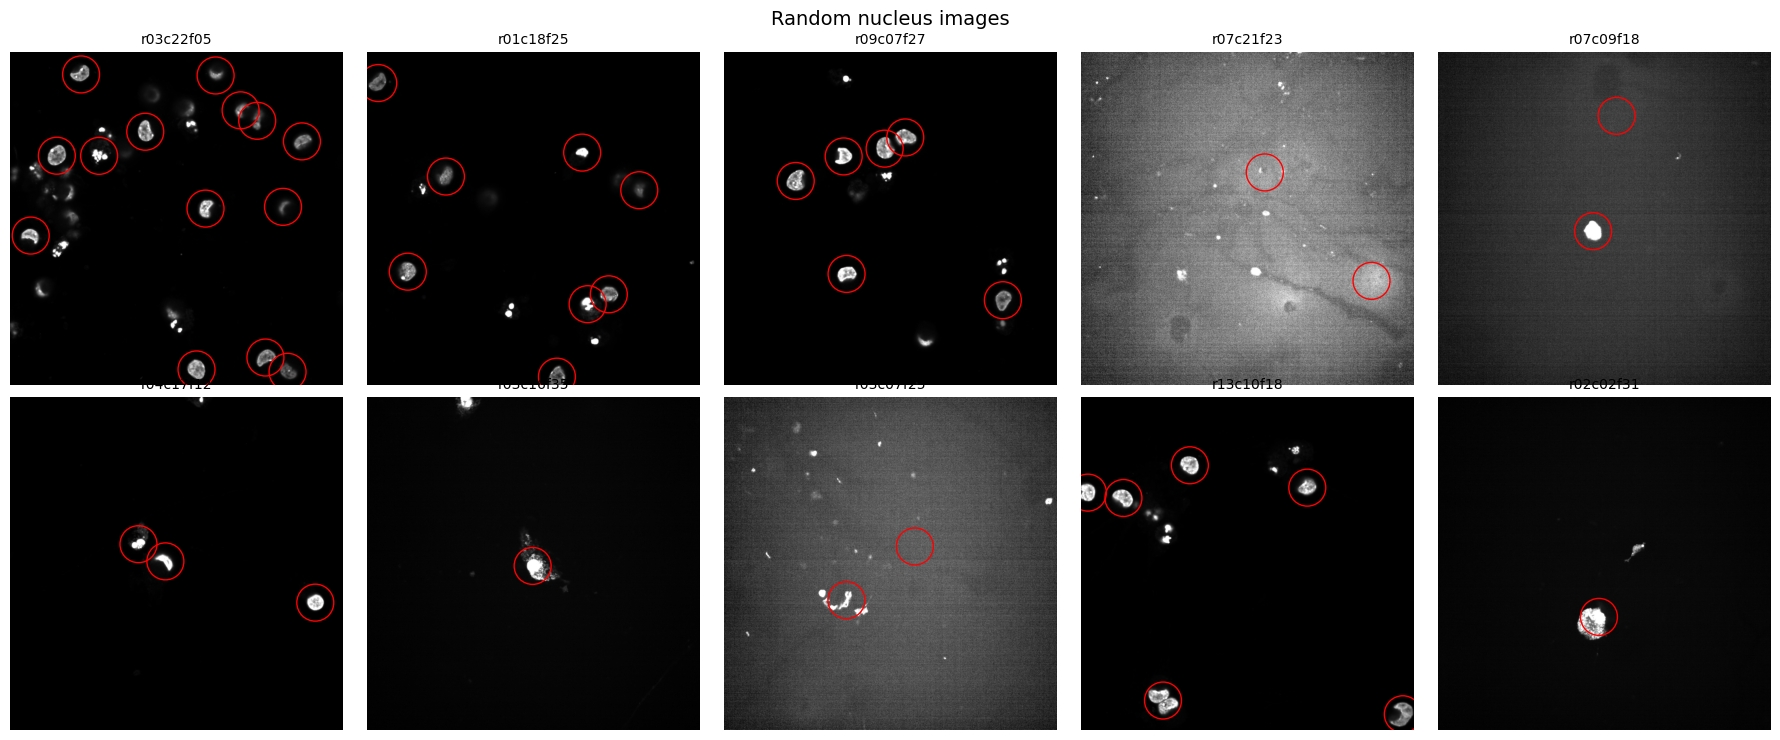

In [6]:
RADIUS = 120  # radius of circle in pixels

# Print 5 random images with circles around their centroids (120 px radius)
experiment_img_dir = experiment_path / "images"
nuc_files = sorted(experiment_img_dir.rglob("*-ch01t01.tiff")) 
print(f"Total number of nucleus images: {len(nuc_files)}")

random.seed(42) 
sample = random.sample(nuc_files, 10)
for img_path in sample:
    print(img_path)

fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))

for ax, fpath in zip(axes.flat, sample):
    img = tifffile.imread(fpath)

    lo, hi = np.percentile(img, (0.2, 99.8))
    ax.imshow(img, cmap="gray", vmin=lo, vmax=hi)

    well = fpath.name.split("p")[0]
    ax.set_title(well, fontsize=10)
    ax.axis("off")

    # Match centroids for this exact image
    sub = nuc_feat_df[nuc_feat_df["image_name"] == fpath.name]

    for _, row in sub.iterrows():
        circ = Circle((row["centroid-1"], row["centroid-0"]),
                      radius=RADIUS, edgecolor="red", facecolor="none", linewidth=1)
        ax.add_patch(circ)

fig.suptitle("Random nucleus images", fontsize=14)
plt.tight_layout()
plt.show()

# Filters

## Frame contrast check

Allocated cores: 32  ->  using 31 workers
[########################################] | 100% Completed | 112.07 s
Contrast computed for 8645 frames


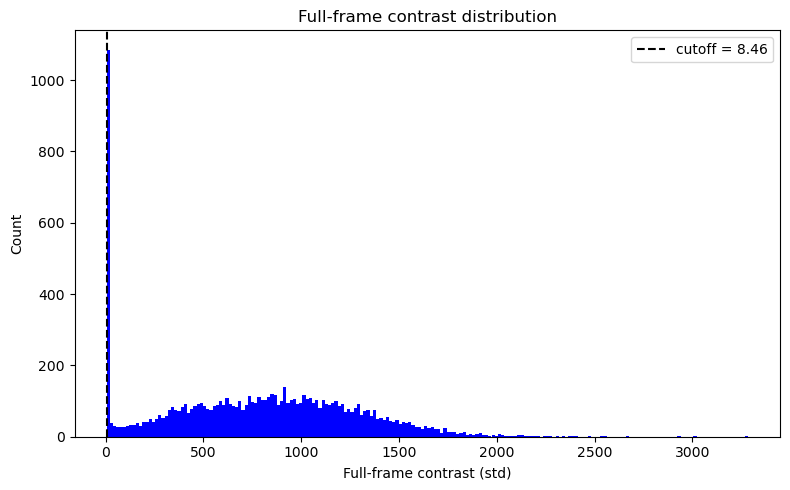

contrast_check
pass    7780
fail     865
Name: count, dtype: int64
                 count      mean       std  min  25%  50%  75%   max
contrast_check                                                      
fail             865.0  1.891329  1.218010  0.0  1.0  2.0  2.0   8.0
pass            7780.0  5.623136  4.540105  0.0  2.0  4.0  8.0  30.0


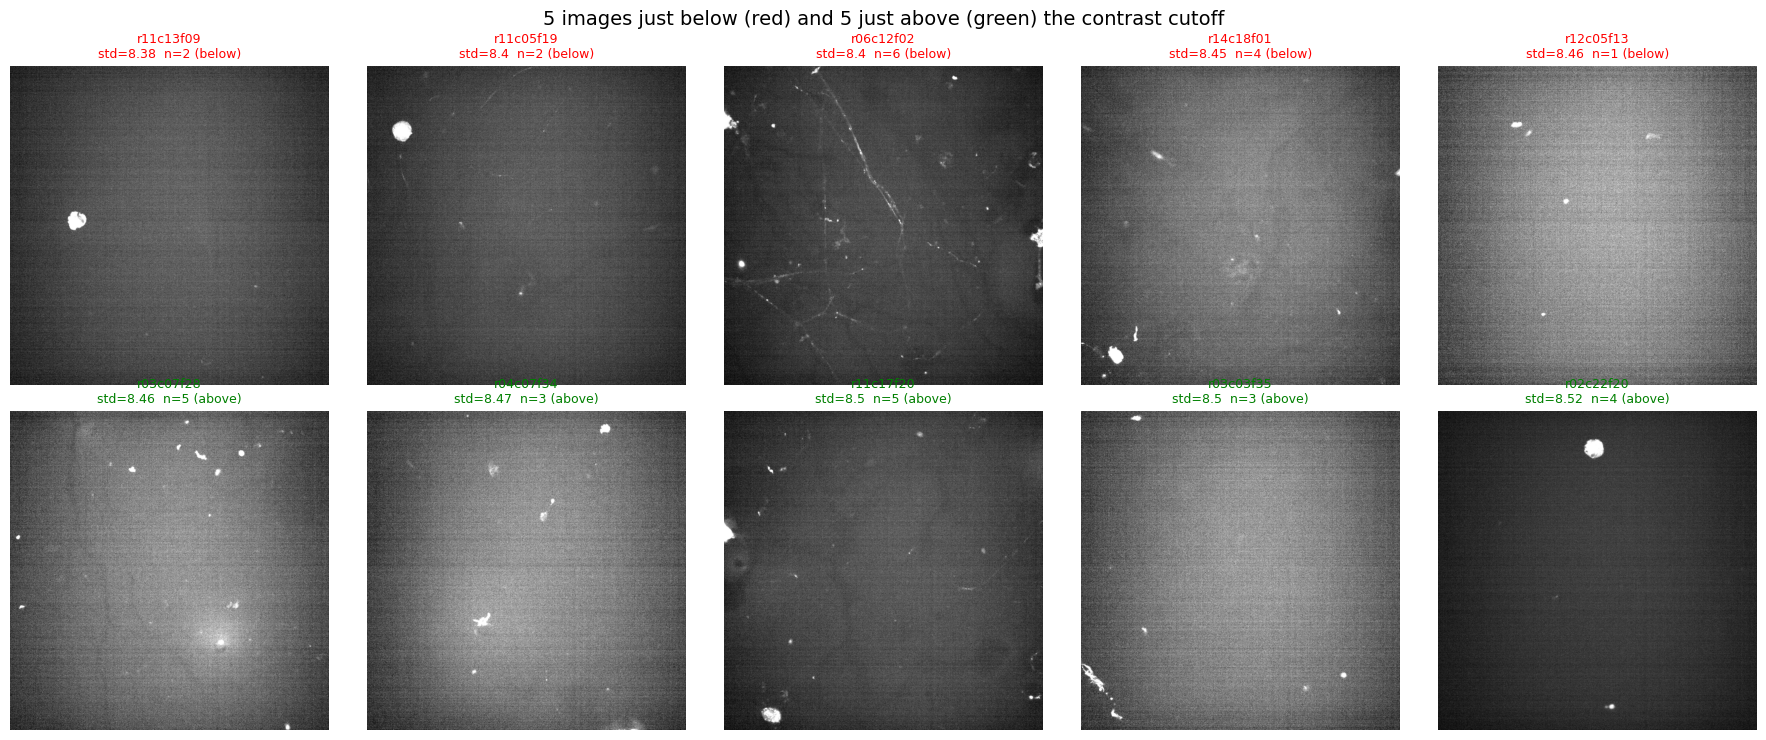

In [ ]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
import dask
from dask.diagnostics import ProgressBar

# ---------------------------------------------------------------
# 0. Determine core count from the SLURM allocation
# ---------------------------------------------------------------
# Falls back to os.cpu_count() if not running under SLURM.
allocated = int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count() or 1))
n_workers = max(1, allocated - 1)
print(f"Allocated cores: {allocated}  ->  using {n_workers} workers")

# ---------------------------------------------------------------
# 1. Compute a full-frame contrast metric for each image (parallel)
# ---------------------------------------------------------------
def frame_contrast(fpath, lo_pct=0.2, hi_pct=99.8):
    img = tifffile.imread(fpath).astype(np.float64)
    mean = img.mean()
    std = img.std()
    lo, hi = np.percentile(img, (lo_pct, hi_pct))
    return {
        "image_name": fpath.name,
        "std": std,
        "rms_contrast": std / mean if mean > 0 else 0.0,
        "p_range": hi - lo,
    }

tasks = [dask.delayed(frame_contrast)(fpath) for fpath in nuc_files]

with dask.config.set(scheduler="threads", num_workers=n_workers), ProgressBar():
    records = dask.compute(*tasks)

contrast_df = pd.DataFrame(records)
print(f"Contrast computed for {len(contrast_df)} frames")

# Cross-reference: how many nuclei were segmented in each frame
nuc_counts = nuc_feat_df["image_name"].value_counts()
contrast_df["n_nuclei"] = contrast_df["image_name"].map(nuc_counts).fillna(0).astype(int)

METRIC = "std"   # or "rms_contrast" / "p_range"


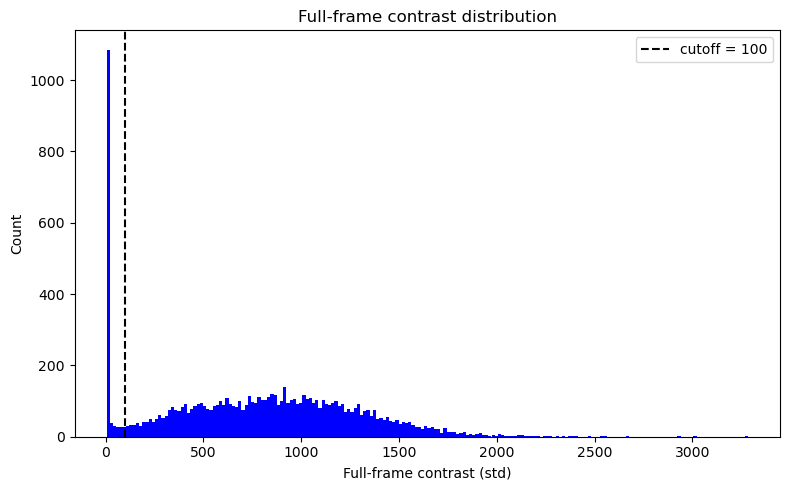

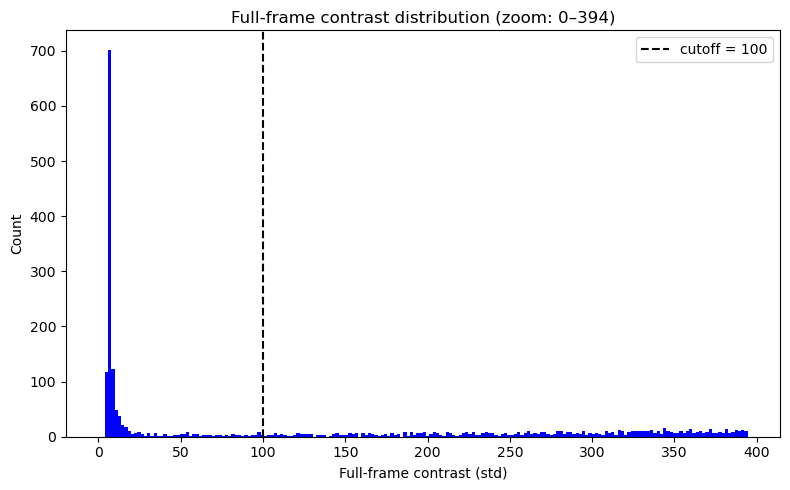

contrast_check
pass    7414
fail    1231
Name: count, dtype: int64
                 count      mean       std  min  25%  50%  75%   max
contrast_check                                                      
fail            1231.0  2.125102  1.569199  0.0  1.0  2.0  3.0  15.0
pass            7414.0  5.768546  4.578921  0.0  2.0  5.0  8.0  30.0


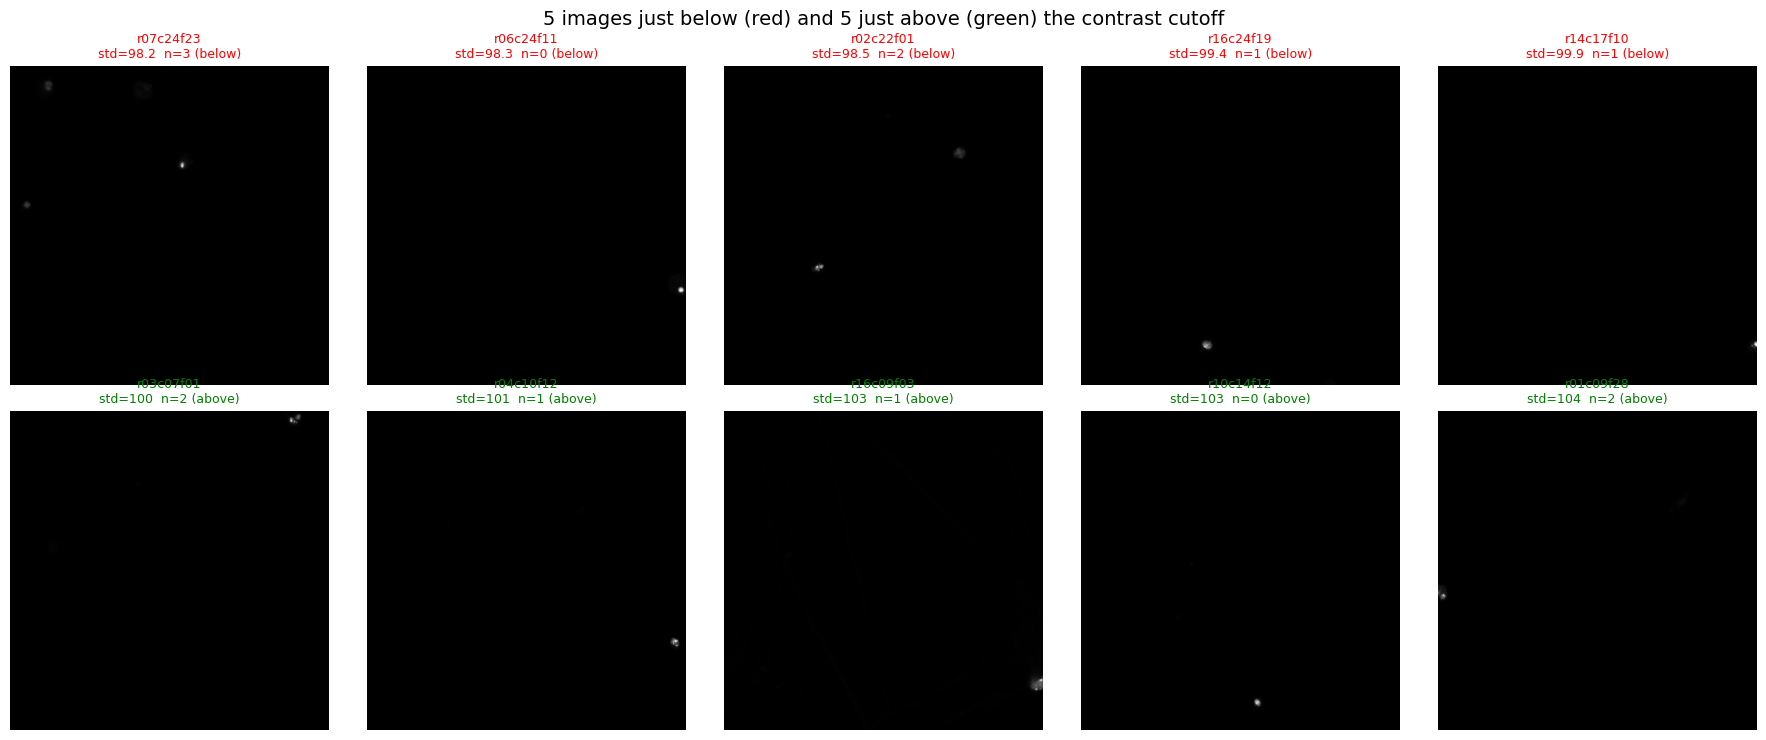

In [18]:
# ---------------------------------------------------------------
# 2. Histogram of full-frame contrast with a candidate cutoff
# ---------------------------------------------------------------
contrast_cutoff = 100   # fixed value, placed in the gap by eye

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(contrast_df[METRIC], bins=200, color="blue")
ax.axvline(contrast_cutoff, color="black", linestyle="--", linewidth=1.5,
           label=f"cutoff = {contrast_cutoff:.3g}")
ax.set_xlabel(f"Full-frame contrast ({METRIC})")
ax.set_ylabel("Count")
ax.set_title("Full-frame contrast distribution")
ax.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 2b. Zoomed histogram — lower 25% of the metric range
# ---------------------------------------------------------------
zoom_max = np.percentile(contrast_df[METRIC], 25)   # or set a fixed value by eye

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(contrast_df[METRIC], bins=200, range=(0, zoom_max), color="blue")
ax.axvline(contrast_cutoff, color="black", linestyle="--", linewidth=1.5,
           label=f"cutoff = {contrast_cutoff:.3g}")
ax.set_xlabel(f"Full-frame contrast ({METRIC})")
ax.set_ylabel("Count")
ax.set_title(f"Full-frame contrast distribution (zoom: 0–{zoom_max:.3g})")
ax.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 3. Apply the check
# ---------------------------------------------------------------
contrast_df["contrast_check"] = np.where(
    contrast_df[METRIC] >= contrast_cutoff, "pass", "fail"
)
print(contrast_df["contrast_check"].value_counts())

# Sanity check: do low-contrast frames actually have fewer nuclei?
print(contrast_df.groupby("contrast_check")["n_nuclei"].describe())

# ---------------------------------------------------------------
# 4. Plot 5 images just below and 5 just above the cutoff
# ---------------------------------------------------------------
sorted_df = contrast_df.sort_values(METRIC).reset_index(drop=True)
above_start = (sorted_df[METRIC] >= contrast_cutoff).idxmax()

below = sorted_df.iloc[max(0, above_start - 5):above_start]
above = sorted_df.iloc[above_start:above_start + 5]
selection = pd.concat([below, above]).reset_index(drop=True)

name_to_path = {p.name: p for p in nuc_files}

fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))

for ax, (_, row) in zip(axes.flat, selection.iterrows()):
    img = tifffile.imread(name_to_path[row["image_name"]])
    # lo, hi = np.percentile(img, (0.2, 99.8))
    ax.imshow(img, cmap="gray")

    side = "below" if row[METRIC] < contrast_cutoff else "above"
    well = row["image_name"].split("p")[0]
    color = "red" if side == "below" else "green"
    ax.set_title(f"{well}\n{METRIC}={row[METRIC]:.3g}  n={row['n_nuclei']} ({side})",
                 fontsize=9, color=color)
    ax.axis("off")

fig.suptitle("5 images just below (red) and 5 just above (green) the contrast cutoff",
             fontsize=14)
plt.tight_layout()
plt.show()

## Edge and ROI overlaps

In [ ]:
H, W = 2160, 2160
circle_area = np.pi * RADIUS**2
area_thresh = 0.05 * circle_area

x = nuc_feat_df["centroid-1"]
y = nuc_feat_df["centroid-0"]

overflow = (
    (x - RADIUS < 0) | (x + RADIUS > W) |
    (y - RADIUS < 0) | (y + RADIUS > H)
)

nuc_feat_df["edge_check"] = np.where(overflow, "fail", "pass")

def lens_area(d, RADIUS):
    """Intersection area of two circles, equal radius r, center distance d."""
    if d >= 2*RADIUS:
        return 0.0
    if d <= 0:
        return circle_area
    return 2 * RADIUS**2 * np.arccos(d / (2*RADIUS)) - (d/2) * np.sqrt(4*RADIUS**2 - d**2)

nuc_feat_df["overlap_check"] = "pass"

for name, grp in nuc_feat_df.groupby("image_name"):
    idx = grp.index.to_numpy()
    xs = grp["centroid-1"].to_numpy()
    ys = grp["centroid-0"].to_numpy()

    # pairwise center distances
    dx = xs[:, None] - xs[None, :]
    dy = ys[:, None] - ys[None, :]
    dist = np.sqrt(dx**2 + dy**2)

    n = len(idx)
    failed = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(i+1, n):
            if dist[i, j] < 2*RADIUS:  # circles touch at all
                if lens_area(dist[i, j], RADIUS) > area_thresh:
                    failed[i] = True
                    failed[j] = True

    nuc_feat_df.loc[idx[failed], "overlap_check"] = "fail"

print(f"Total number of nuclei in experiment: {len(nuc_feat_df)}")
print("************************************************")
print(nuc_feat_df["edge_check"].value_counts())
print("************************************************")
print(nuc_feat_df["overlap_check"].value_counts())
print("************************************************")
print(pd.crosstab(nuc_feat_df["edge_check"], nuc_feat_df["overlap_check"]))

## Nucleus area cutoff

In [ ]:
print(nuc_feat_df["area"].describe().apply(lambda x: f"{x:,.1f}"))

In [ ]:
res = 0.09418670872212731
small_cutoff_px2 = 20 / res**2      # 2,255 px²; the segementation algorithm actually cuts off at 3500 px²
large_cutoff_px2 = 150 / res**2     # 22,545 px²

# plot of nucleus area distribution
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(nuc_feat_df["area"], bins=1000, color="blue")

ax.axvline(small_cutoff_px2, color="black", linestyle="--", linewidth=1.5,
           label=f"20 µm² ≈ {small_cutoff_px2:.0f} px²")
ax.axvline(large_cutoff_px2, color="black", linestyle="--", linewidth=1.5,
           label=f"200 µm² ≈ {large_cutoff_px2:.0f} px²")

ax.set_xlabel("Nucleus area")
ax.set_ylabel("Count")
ax.set_title("Nucleus area distribution")
ax.legend()

plt.tight_layout()
plt.show()

in_range = (nuc_feat_df["area"] >= small_cutoff_px2) & (nuc_feat_df["area"] <= large_cutoff_px2)
nuc_feat_df["area_check"] = np.where(in_range, "pass", "fail")

print(nuc_feat_df["area_check"].value_counts())

passing = nuc_feat_df[nuc_feat_df["area_check"] == "pass"]

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(passing["area"], bins=500, range=(small_cutoff_px2, large_cutoff_px2),
        color="blue")

ax.axvline(small_cutoff_px2, color="black", linestyle="--", linewidth=1.5,
           label=f"20 µm² ≈ {small_cutoff_px2:.0f} px²")
ax.axvline(large_cutoff_px2, color="black", linestyle="--", linewidth=1.5,
           label=f"200 µm² ≈ {large_cutoff_px2:.0f} px²")

ax.set_xlabel("Nucleus area")
ax.set_ylabel("Count")
ax.set_title("Nucleus area distribution (passing area check)")
ax.legend()

plt.tight_layout()
plt.show()

top_images = (
    passing.groupby("image_name")["area"].max()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

# Map image_name -> full path
name_to_path = {p.name: p for p in nuc_files}

fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))

for ax, img_name in zip(axes.flat, top_images):
    fpath = name_to_path[img_name]
    img = tifffile.imread(fpath)

    lo, hi = np.percentile(img, (0.2, 99.8))
    ax.imshow(img, cmap="gray", vmin=lo, vmax=hi)

    sub = passing[passing["image_name"] == img_name]
    largest_idx = sub["area"].idxmax()   # the single largest nucleus in this image

    well = img_name.split("p")[0]
    ax.set_title(f"{well}", fontsize=9)
    ax.axis("off")

    for i, row in sub.iterrows():
        color = "yellow" if i == largest_idx else "red"
        lw = 1.5 if i == largest_idx else 1
        circ = Circle((row["centroid-1"], row["centroid-0"]),
                      radius=RADIUS, edgecolor=color, facecolor="none", linewidth=lw)
        ax.add_patch(circ)

fig.suptitle("10 images with largest nuclei (passing area check)", fontsize=14)
plt.tight_layout()
plt.show()

## Nucleus perimeter cutoff

In [ ]:
large_cutoff_px = 1000

# plot of nucleus perimeter distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(nuc_feat_df["perimeter"], bins=1000, color="blue")
ax.axvline(large_cutoff_px, color="black", linestyle="--", linewidth=1.5,
           label=f"cutoff = {large_cutoff_px} px")
ax.set_xlabel("Nucleus perimeter")
ax.set_ylabel("Count")
ax.set_title("Nucleus perimeter distribution")
ax.legend()
plt.tight_layout()
plt.show()

nuc_feat_df["perimeter_check"] = np.where(
    nuc_feat_df["perimeter"] <= large_cutoff_px, "pass", "fail"
)
print(nuc_feat_df["perimeter_check"].value_counts())

passing = nuc_feat_df[nuc_feat_df["perimeter_check"] == "pass"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(passing["perimeter"], bins=500, range=(0, large_cutoff_px), color="blue")
ax.axvline(large_cutoff_px, color="black", linestyle="--", linewidth=1.5,
           label=f"cutoff = {large_cutoff_px} px")
ax.set_xlabel("Nucleus perimeter")
ax.set_ylabel("Count")
ax.set_title("Nucleus perimeter distribution (passing perimeter check)")
ax.legend()
plt.tight_layout()
plt.show()

# Passing (perimeter) nuclei, ranked by each image's largest-perimeter nucleus
top_images = (
    passing.groupby("image_name")["perimeter"].max()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

# Map image_name -> full path
name_to_path = {p.name: p for p in nuc_files}

fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))

for ax, img_name in zip(axes.flat, top_images):
    fpath = name_to_path[img_name]
    img = tifffile.imread(fpath)

    lo, hi = np.percentile(img, (0.2, 99.8))
    ax.imshow(img, cmap="gray", vmin=lo, vmax=hi)

    sub = passing[passing["image_name"] == img_name]
    largest_idx = sub["perimeter"].idxmax()   # largest-perimeter nucleus in this image

    well = img_name.split("p")[0]
    ax.set_title(f"{well}", fontsize=9)
    ax.axis("off")

    for i, row in sub.iterrows():
        color = "yellow" if i == largest_idx else "red"
        lw = 1.5 if i == largest_idx else 1
        circ = Circle((row["centroid-1"], row["centroid-0"]),
                      radius=RADIUS, edgecolor=color, facecolor="none", linewidth=lw)
        ax.add_patch(circ)

fig.suptitle("10 images with largest-perimeter nuclei (passing perimeter check)", fontsize=14)
plt.tight_layout()
plt.show()

## Nucleus max intensity cutoff

In [ ]:
cutoff = 500

# plot of nucleus max_intensity distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(nuc_feat_df["max_intensity"], bins=1000, color="blue")
ax.axvline(cutoff, color="black", linestyle="--", linewidth=1.5,
           label=f"cutoff = {cutoff}")
ax.set_xlabel("Nucleus max intensity")
ax.set_ylabel("Count")
ax.set_title("Nucleus max intensity distribution")
ax.legend()
plt.tight_layout()
plt.show()

nuc_feat_df["intensity_check"] = np.where(
    nuc_feat_df["max_intensity"] > cutoff, "pass", "fail"
)
print(nuc_feat_df["intensity_check"].value_counts())

passing = nuc_feat_df[nuc_feat_df["intensity_check"] == "pass"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(passing["max_intensity"], bins=500, color="blue")
ax.axvline(cutoff, color="black", linestyle="--", linewidth=1.5,
           label=f"cutoff = {cutoff}")
ax.set_xlabel("Nucleus max intensity")
ax.set_ylabel("Count")
ax.set_title("Nucleus max intensity distribution (passing intensity check)")
ax.legend()
plt.tight_layout()
plt.show()

# Passing nuclei, ranked by each image's largest max_intensity
top_images = (
    passing.groupby("image_name")["max_intensity"].max()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

# Map image_name -> full path
name_to_path = {p.name: p for p in nuc_files}

fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))

for ax, img_name in zip(axes.flat, top_images):
    fpath = name_to_path[img_name]
    img = tifffile.imread(fpath)

    lo, hi = np.percentile(img, (0.2, 99.8))
    ax.imshow(img, cmap="gray", vmin=lo, vmax=hi)

    sub = passing[passing["image_name"] == img_name]
    largest_idx = sub["max_intensity"].idxmax()   # brightest nucleus in this image

    well = img_name.split("p")[0]
    ax.set_title(f"{well}", fontsize=9)
    ax.axis("off")

    for i, row in sub.iterrows():
        color = "yellow" if i == largest_idx else "red"
        lw = 1.5 if i == largest_idx else 1
        circ = Circle((row["centroid-1"], row["centroid-0"]),
                      radius=RADIUS, edgecolor=color, facecolor="none", linewidth=lw)
        ax.add_patch(circ)

fig.suptitle("10 images with brightest nuclei (passing intensity check)", fontsize=14)
plt.tight_layout()
plt.show()

# Passing nuclei, ranked by each image's dimmest nucleus
top_images = (
    passing.groupby("image_name")["max_intensity"].min()
    .sort_values(ascending=True)     # ascending → dimmest images first
    .head(10)
    .index.tolist()
)

name_to_path = {p.name: p for p in nuc_files}

fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))

for ax, img_name in zip(axes.flat, top_images):
    fpath = name_to_path[img_name]
    img = tifffile.imread(fpath)

    lo, hi = np.percentile(img, (0.2, 99.8))
    ax.imshow(img, cmap="gray", vmin=lo, vmax=hi)

    sub = passing[passing["image_name"] == img_name]
    dimmest_idx = sub["max_intensity"].idxmin()   # dimmest nucleus in this image

    well = img_name.split("p")[0]
    ax.set_title(f"{well}", fontsize=9)
    ax.axis("off")

    for i, row in sub.iterrows():
        color = "yellow" if i == dimmest_idx else "red"
        lw = 1.5 if i == dimmest_idx else 1
        circ = Circle((row["centroid-1"], row["centroid-0"]),
                      radius=RADIUS, edgecolor=color, facecolor="none", linewidth=lw)
        ax.add_patch(circ)

fig.suptitle("10 images with dimmest nuclei (passing intensity check)", fontsize=14)
plt.tight_layout()
plt.show()

## Nucleus solidity cutoff

Solidity = object area / convex hull area \
Essentially a measure of compactness, NOT circularity

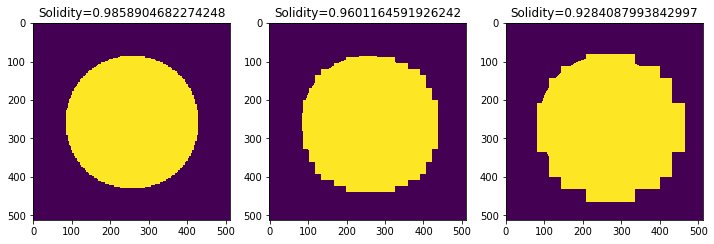

Ref: [Metric for concavity of objects in skimage](https://stackoverflow.com/questions/54604771/metric-for-concavity-of-objects-in-skimage-or-in-general-in-python)

In [ ]:
cutoff = 0.6   #

# plot of nucleus solidity distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(nuc_feat_df["solidity"], bins=1000, color="blue")
ax.axvline(cutoff, color="black", linestyle="--", linewidth=1.5,
           label=f"cutoff = {cutoff}")
ax.set_xlabel("Nucleus solidity")
ax.set_ylabel("Count")
ax.set_title("Nucleus solidity distribution")
ax.legend()
plt.tight_layout()
plt.show()

nuc_feat_df["solidity_check"] = np.where(
    nuc_feat_df["solidity"] >= cutoff, "pass", "fail"
)
print(nuc_feat_df["solidity_check"].value_counts())

passing = nuc_feat_df[nuc_feat_df["solidity_check"] == "pass"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(passing["solidity"], bins=500, range=(cutoff, 1.0), color="blue")
ax.axvline(cutoff, color="black", linestyle="--", linewidth=1.5,
           label=f"cutoff = {cutoff}")
ax.set_xlabel("Nucleus solidity")
ax.set_ylabel("Count")
ax.set_title("Nucleus solidity distribution (passing solidity check)")
ax.legend()
plt.tight_layout()
plt.show()

name_to_path = {p.name: p for p in nuc_files}

# ---- 10 images with highest-solidity nuclei ----
top_images = (
    passing.groupby("image_name")["solidity"].max()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))
for ax, img_name in zip(axes.flat, top_images):
    fpath = name_to_path[img_name]
    img = tifffile.imread(fpath)
    lo, hi = np.percentile(img, (0.2, 99.8))
    ax.imshow(img, cmap="gray", vmin=lo, vmax=hi)

    sub = passing[passing["image_name"] == img_name]
    extreme_idx = sub["solidity"].idxmax()

    ax.set_title(f"{img_name.split('p')[0]}", fontsize=9)
    ax.axis("off")
    for i, row in sub.iterrows():
        color = "yellow" if i == extreme_idx else "red"
        lw = 1.5 if i == extreme_idx else 1
        circ = Circle((row["centroid-1"], row["centroid-0"]),
                      radius=RADIUS, edgecolor=color, facecolor="none", linewidth=lw)
        ax.add_patch(circ)

fig.suptitle("10 images with highest-solidity nuclei (passing solidity check)", fontsize=14)
plt.tight_layout()
plt.show()

# ---- 10 images with lowest-solidity nuclei ----
top_images = (
    passing.groupby("image_name")["solidity"].min()
    .sort_values(ascending=True)
    .head(10)
    .index.tolist()
)

fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))
for ax, img_name in zip(axes.flat, top_images):
    fpath = name_to_path[img_name]
    img = tifffile.imread(fpath)
    lo, hi = np.percentile(img, (0.2, 99.8))
    ax.imshow(img, cmap="gray", vmin=lo, vmax=hi)

    sub = passing[passing["image_name"] == img_name]
    extreme_idx = sub["solidity"].idxmin()

    ax.set_title(f"{img_name.split('p')[0]}", fontsize=9)
    ax.axis("off")
    for i, row in sub.iterrows():
        color = "yellow" if i == extreme_idx else "red"
        lw = 1.5 if i == extreme_idx else 1
        circ = Circle((row["centroid-1"], row["centroid-0"]),
                      radius=RADIUS, edgecolor=color, facecolor="none", linewidth=lw)
        ax.add_patch(circ)

fig.suptitle("10 images with lowest-solidity nuclei (passing solidity check)", fontsize=14)
plt.tight_layout()
plt.show()

## Frame contrast cutoff
Testing!!

In [ ]:
name_to_path = {p.name: p for p in nuc_files}

# Per-frame contrast metric, merged onto the df as a column
def frame_contrast(img):
    p1, p99 = np.percentile(img, (1, 99))
    return p99 - p1

# only run this if necessary, slow!
# contrast = {name: frame_contrast(tifffile.imread(name_to_path[name]))
#             for name in nuc_feat_df["image_name"].unique()}
# nuc_feat_df["contrast"] = nuc_feat_df["image_name"].map(contrast)

cutoff = 30   # somewhere in the range of 30-50 is probably the right cutoff

# plot of contrast distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(nuc_feat_df["contrast"], bins=1000, color="blue")
ax.axvline(cutoff, color="black", linestyle="--", linewidth=1.5,
           label=f"cutoff = {cutoff}")
ax.set_xlabel("Frame contrast")
ax.set_ylabel("Count")
ax.set_title("Frame contrast distribution")
ax.legend()
plt.tight_layout()
plt.show()

nuc_feat_df["contrast_check"] = np.where(
    nuc_feat_df["contrast"] > cutoff, "pass", "fail"
)
print(nuc_feat_df["contrast_check"].value_counts())

passing = nuc_feat_df[nuc_feat_df["contrast_check"] == "pass"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(passing["contrast"], bins=500, color="blue")
ax.axvline(cutoff, color="black", linestyle="--", linewidth=1.5,
           label=f"cutoff = {cutoff}")
ax.set_xlabel("Frame contrast")
ax.set_ylabel("Count")
ax.set_title("Frame contrast distribution (passing contrast check)")
ax.legend()
plt.tight_layout()
plt.show()

# ---- 10 highest-contrast frames ----
top_images = (
    passing.groupby("image_name")["contrast"].max()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))
for ax, img_name in zip(axes.flat, top_images):
    img = tifffile.imread(name_to_path[img_name])
    lo, hi = np.percentile(img, (0.2, 99.8))
    ax.imshow(img, cmap="gray", vmin=lo, vmax=hi)

    sub = passing[passing["image_name"] == img_name]
    extreme_idx = sub["contrast"].idxmax()

    ax.set_title(f"{img_name.split('p')[0]}", fontsize=9)
    ax.axis("off")
    for i, row in sub.iterrows():
        color = "yellow" if i == extreme_idx else "red"
        lw = 1.5 if i == extreme_idx else 1
        circ = Circle((row["centroid-1"], row["centroid-0"]),
                      radius=RADIUS, edgecolor=color, facecolor="none", linewidth=lw)
        ax.add_patch(circ)

fig.suptitle("10 highest-contrast frames (passing contrast check)", fontsize=14)
plt.tight_layout()
plt.show()

# ---- 10 lowest-contrast frames ----
top_images = (
    passing.groupby("image_name")["contrast"].min()
    .sort_values(ascending=True)
    .head(10)
    .index.tolist()
)

fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))
for ax, img_name in zip(axes.flat, top_images):
    img = tifffile.imread(name_to_path[img_name])
    lo, hi = np.percentile(img, (0.2, 99.8))
    ax.imshow(img, cmap="gray", vmin=lo, vmax=hi)

    sub = passing[passing["image_name"] == img_name]
    extreme_idx = sub["contrast"].idxmin()

    ax.set_title(f"{img_name.split('p')[0]}", fontsize=9)
    ax.axis("off")
    for i, row in sub.iterrows():
        color = "yellow" if i == extreme_idx else "red"
        lw = 1.5 if i == extreme_idx else 1
        circ = Circle((row["centroid-1"], row["centroid-0"]),
                      radius=RADIUS, edgecolor=color, facecolor="none", linewidth=lw)
        ax.add_patch(circ)

fig.suptitle("10 lowest-contrast frames (passing contrast check)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
nuc_feat_df["well"] = nuc_feat_df["image_name"].str.split("f").str[0]
frame_level = nuc_feat_df.drop_duplicates("image_name")[["well", "image_name", "contrast_check"]]

frame_level = frame_level.copy()
frame_level["row"] = frame_level["well"].str.extract(r"(r\d+)")
frame_level["col"] = frame_level["well"].str.extract(r"(c\d+)")
frame_level["fail"] = frame_level["contrast_check"].eq("fail")

# fraction failing (for color) and count failing (for annotation)
plate = frame_level.groupby(["row", "col"])["fail"].mean().unstack("col")
counts = frame_level.groupby(["row", "col"])["fail"].sum().unstack("col")

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(plate.values, cmap="viridis", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(plate.columns)))
ax.set_xticklabels(plate.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(plate.index)))
ax.set_yticklabels(plate.index, fontsize=7)
ax.set_title("Contrast failure rate by well")
fig.colorbar(im, ax=ax, label="Fraction of frames failing")

# annotate each cell with the fail count
for i in range(plate.shape[0]):
    for j in range(plate.shape[1]):
        val = plate.values[i, j]
        cnt = counts.values[i, j]
        if not np.isnan(val):
            # white text on dark cells, black on bright cells
            color = "white" if val < 0.5 else "black"
            ax.text(j, i, f"{int(cnt)}", ha="center", va="center",
                    color=color, fontsize=6)

plt.tight_layout()
plt.show()

# Cutoff crosscheck and image check

In [ ]:
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)

In [ ]:
# cross validation list
print(f"Total number of nuclei in experiment: {len(nuc_feat_df)}")
print("************************************************")
print(nuc_feat_df.groupby(
    [
        "area_check", 
        "perimeter_check", 
        "intensity_check", 
        "solidity_check", 
        "contrast_check",
        ]
).size().reset_index(name="count"))

In [ ]:
def show_random_images(df, n=10, title="Random images", seed=42):
    """Plot n random images from df, with all of df's nuclei in each image circled."""
    name_to_path = {p.name: p for p in nuc_files}

    # sample from the images present in this (subsetted) df
    img_names = df["image_name"].unique()
    n = min(n, len(img_names))
    rng = random.Random(seed)
    sample = rng.sample(list(img_names), n)

    fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))
    for ax, img_name in zip(axes.flat, sample):
        img = tifffile.imread(name_to_path[img_name])
        lo, hi = np.percentile(img, (0.2, 99.8))
        ax.imshow(img, cmap="gray", vmin=lo, vmax=hi)

        sub = df[df["image_name"] == img_name]
        ax.set_title(f"{img_name.split('p')[0]}", fontsize=9)
        ax.axis("off")
        for _, row in sub.iterrows():
            circ = Circle((row["centroid-1"], row["centroid-0"]),
                          radius=RADIUS, edgecolor="red", facecolor="none", linewidth=1)
            ax.add_patch(circ)

    # hide any unused axes if fewer than 10 images
    for ax in axes.flat[n:]:
        ax.axis("off")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# nuclei passing everything
passing_all = nuc_feat_df[
    (nuc_feat_df[["area_check","perimeter_check","intensity_check",
                  "solidity_check","contrast_check"]] == "pass").all(axis=1)
]
show_random_images(passing_all, title="Random passing images")

# or nuclei failing a specific check, to inspect what gets removed
failed_solidity = nuc_feat_df[nuc_feat_df["solidity_check"] == "fail"]
show_random_images(failed_solidity, title="Random solidity failures")

# Fail contrast only
other_checks = ["area_check", "perimeter_check", "intensity_check", "solidity_check"]

failed_contrast_only = nuc_feat_df[
    (nuc_feat_df["contrast_check"] == "fail") &
    (nuc_feat_df[other_checks] == "pass").all(axis=1)
]
show_random_images(failed_contrast_only, title="Random contrast ONLY failures")